# 🛍️ ¿Cuál es el mejor momento del año para comprar? 📅
### Análisis de mercado de 3 productos: Televisor 32", Computador de gama baja e iPhone
#### Proyecto de Análisis de Mercados de Productos — Alkosto, Bogotá, Colombia

¡Hola! 👋 Este cuaderno es como un **detective de ofertas** 🕵️. Su misión es descubrir en qué **mes del año**
conviene más comprar cada uno de estos 3 productos:

1. 📺 Un **televisor de 32 pulgadas**
2. 💻 Un **computador de gama baja** (uno económico, sencillo)
3. 📱 Un **iPhone**

**¿Cómo lo vamos a averiguar?** Vamos a mirar 3 pistas, como si armáramos un rompecabezas 🧩:

- 🔎 **Pista 1 — Qué tanto busca la gente estos productos en Google**, mes a mes, durante los últimos años.
  Cuando MENOS gente busca un producto, muchas veces las tiendas bajan el precio para atraer compradores. 📉
- 💵 **Pista 2 — Cuánto vale el dólar en pesos colombianos**, porque estos 3 productos vienen de fábricas en
  otros países y se pagan en dólares. Si el dólar está "barato" en pesos, es más probable que los precios
  bajen un poco. 🌎
- 🎉 **Pista 3 — Las fechas de descuentos oficiales en Colombia**, como el "Día sin IVA", el Black Friday,
  el Cyber Monday, el Hot Sale y la temporada de Navidad.

Al final, juntamos las 3 pistas y te decimos: *"este mes parece el mejor momento para comprar cada producto"*.

---

> ⚠️ **Muy importante, léelo con atención:**
> Este cuaderno **NO tiene acceso a los precios exactos y privados de Alkosto** (esos datos no son públicos ni
> están disponibles en tiempo real gratis). En su lugar, usamos **pistas públicas y reales** (búsquedas de Google
> y el precio del dólar) para hacer una **predicción educada**, como cuando un detective junta pistas para
> resolver un caso, aunque no haya visto el crimen con sus propios ojos. 🔍
>
> Esto es un **ejercicio académico**. Antes de comprar de verdad, siempre compara el precio actual en la
> página de Alkosto o en la tienda física. 🛒

**¿Cómo se usa este cuaderno?** Sube este archivo a Google Colab y ejecuta las celdas de código (los cuadros
grises) de arriba hacia abajo, dándole clic al botón ▶️ de cada una.


## 1️⃣ Preparar las herramientas 🧰

Igual que un detective necesita su lupa 🔎 y su libreta de notas 📓, nosotros necesitamos instalar
unas "cajas de herramientas" de Python antes de empezar la investigación.

La herramienta nueva que usaremos aquí es **`pytrends`**, que nos deja "preguntarle a Google" qué tanto
ha buscado la gente cada producto, mes a mes, ¡totalmente gratis y sin necesitar una clave secreta!


In [1]:
# Instalamos las herramientas necesarias.
# pytrends: para consultar Google Trends (qué tanto busca la gente algo)
# requests, pandas, numpy, matplotlib: nuestras herramientas de siempre
!pip install pytrends requests pandas numpy matplotlib --quiet

print("✅ ¡Listo! Ya tenemos todas nuestras herramientas de detective preparadas.")


✅ ¡Listo! Ya tenemos todas nuestras herramientas de detective preparadas.


## 2️⃣ Traer las herramientas a la mesa de trabajo

Ahora "sacamos" cada herramienta de su caja para poder usarla:

- `pytrends` 🔎 → para preguntarle a Google Trends qué tanto se busca cada producto.
- `requests` 🌐 → para pedir el precio del dólar por internet.
- `pandas` 📊 → para organizar todo en tablas, como en Excel.
- `numpy` 🔢 → para hacer cuentas.
- `matplotlib` 🎨 → para dibujar gráficas.


In [2]:
import time
from datetime import datetime, timedelta
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytrends.request import TrendReq

# Hacemos que las gráficas se vean grandes y claras
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ Herramientas listas sobre la mesa. ¡Empecemos la investigación!")


✅ Herramientas listas sobre la mesa. ¡Empecemos la investigación!


## 3️⃣ Nuestros 3 sospechosos... digo, productos 🕵️📺💻📱

Antes de investigar, escribimos claramente qué productos vamos a estudiar y qué palabras
vamos a usar para buscarlos en Google (como cuando un detective anota el nombre del sospechoso
en su libreta).


In [3]:
# Diccionario con los productos y el término de búsqueda que usaremos para cada uno.
# (Elegimos palabras comunes, como las escribiría cualquier persona en Colombia buscando el producto)
productos = {
    "Televisor 32 pulgadas": "televisor 32 pulgadas",
    "Computador gama baja": "computador barato",
    "iPhone": "iphone"
}

for nombre, termino_busqueda in productos.items():
    print(f"📦 {nombre}  ->  término de búsqueda: '{termino_busqueda}'")


📦 Televisor 32 pulgadas  ->  término de búsqueda: 'televisor 32 pulgadas'
📦 Computador gama baja  ->  término de búsqueda: 'computador barato'
📦 iPhone  ->  término de búsqueda: 'iphone'


## 4️⃣ Pista #1: ¿Cuándo busca menos la gente cada producto? 🔎📉

Vamos a preguntarle a **Google Trends** (una base de datos pública y gratuita de Google) qué tanto
se ha buscado cada producto **en Colombia**, semana a semana, durante los **últimos 5 años**.

La idea es esta: imagina una juguetería 🧸. Cuando es diciembre, TODOS quieren el juguete de moda,
así que la tienda no necesita bajar el precio (¡se vende solo!). Pero en marzo, casi nadie lo busca,
así que la tienda hace una oferta para llamar la atención. Algo parecido pasa con la tecnología: en
los meses donde MENOS gente busca un producto, es más probable encontrar descuentos para "reactivar" las ventas.


In [4]:
# Nos conectamos a Google Trends, indicando idioma español y zona horaria de Colombia (UTC-5 -> -300 min)
pytrends = TrendReq(hl="es-CO", tz=360)

# Aquí guardaremos los resultados de cada producto
datos_tendencias = {}

for nombre, termino in productos.items():
    print(f"🔎 Consultando Google Trends para: {nombre} ...")
    try:
        # Le pedimos a Google: "muéstrame el interés de búsqueda de este término,
        # en Colombia (geo='CO'), durante los últimos 5 años"
        pytrends.build_payload([termino], geo="CO", timeframe="today 5-y")
        resultado = pytrends.interest_over_time()

        if not resultado.empty:
            datos_tendencias[nombre] = resultado[termino]
            print(f"   ✅ Conseguimos {len(resultado)} semanas de datos.")
        else:
            print(f"   ⚠️ Google no devolvió datos para '{termino}'. Puede que el término sea poco buscado.")

        # Esperamos un poquito entre cada consulta para no "molestar" al servidor de Google
        time.sleep(2)

    except Exception as error:
        print(f"   ❌ No se pudo consultar '{termino}' en este momento. Error: {error}")
        print("   💡 Tip: si esto falla, espera unos minutos y vuelve a ejecutar esta celda.")

print("\n📋 Productos con datos obtenidos con éxito:", list(datos_tendencias.keys()))


🔎 Consultando Google Trends para: Televisor 32 pulgadas ...


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


   ✅ Conseguimos 262 semanas de datos.
🔎 Consultando Google Trends para: Computador gama baja ...


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


   ✅ Conseguimos 262 semanas de datos.
🔎 Consultando Google Trends para: iPhone ...


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


   ✅ Conseguimos 262 semanas de datos.

📋 Productos con datos obtenidos con éxito: ['Televisor 32 pulgadas', 'Computador gama baja', 'iPhone']


## 5️⃣ Ordenar las pistas en una sola tabla 🗂️

Ahora juntamos los datos de los 3 productos en una sola tabla, para poder compararlos fácilmente,
como cuando ordenas todas las pistas de un caso encima de tu escritorio.


In [5]:
# Juntamos todas las series de datos en un solo DataFrame (una tabla grande)
if len(datos_tendencias) > 0:
    df_tendencias = pd.DataFrame(datos_tendencias)
    df_tendencias.index.name = "fecha"
    df_tendencias = df_tendencias.reset_index()

    print(f"✅ Tabla final con {len(df_tendencias)} semanas y {len(datos_tendencias)} productos.")
    df_tendencias.tail()
else:
    print("⚠️ No se pudo obtener ningún dato de Google Trends. Vuelve a ejecutar la celda anterior en unos minutos.")


✅ Tabla final con 262 semanas y 3 productos.


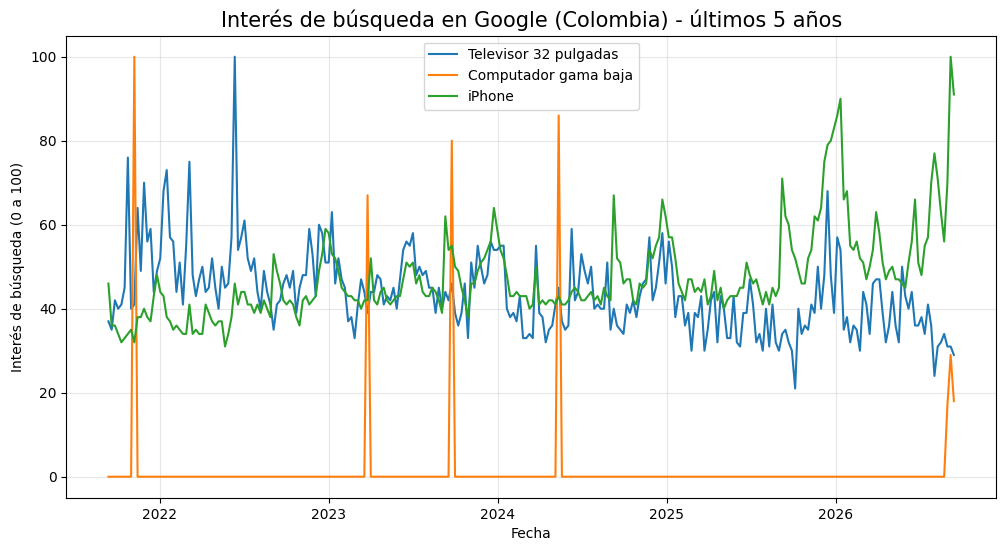

ℹ️ El eje Y va de 0 a 100: 100 significa 'el momento de MÁS búsquedas' y 0 significa 'casi nadie buscó'.


In [6]:
# Graficamos el interés de búsqueda de los 3 productos a lo largo del tiempo
plt.figure()
for nombre in datos_tendencias.keys():
    plt.plot(df_tendencias["fecha"], df_tendencias[nombre], label=nombre, linewidth=1.5)

plt.title("Interés de búsqueda en Google (Colombia) - últimos 5 años", fontsize=15)
plt.xlabel("Fecha")
plt.ylabel("Interés de búsqueda (0 a 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ℹ️ El eje Y va de 0 a 100: 100 significa 'el momento de MÁS búsquedas' y 0 significa 'casi nadie buscó'.")


## 6️⃣ Buscar el patrón: ¿qué mes es siempre más tranquilo? 🗓️

Una sola gráfica con 5 años de datos puede verse muy "ruidosa" (como escuchar a 5 personas hablando
a la vez 🗣️🗣️🗣️). Para encontrar el PATRÓN que se repite cada año, vamos a calcular el promedio de
interés de búsqueda **por mes**, juntando los 5 años. Así descubrimos si, por ejemplo, "cada abril"
la gente busca menos un producto, sin importar el año.


In [7]:
# Extraemos el mes de cada fecha (1 = enero, 2 = febrero, ..., 12 = diciembre)
df_tendencias["mes"] = df_tendencias["fecha"].dt.month
df_tendencias["nombre_mes"] = df_tendencias["fecha"].dt.strftime("%B")

# Calculamos el promedio de interés de búsqueda por mes, para cada producto
promedio_por_mes = df_tendencias.groupby("mes")[list(datos_tendencias.keys())].mean()

nombres_meses_es = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
    7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}
promedio_por_mes.index = promedio_por_mes.index.map(nombres_meses_es)

print("📊 Promedio de interés de búsqueda por mes (juntando los últimos 5 años):")
promedio_por_mes.round(1)


📊 Promedio de interés de búsqueda por mes (juntando los últimos 5 años):


,Televisor 32 pulgadas,Computador gama baja,iPhone
mes,,,
Enero,51.1,0.0,53.3
Febrero,38.8,0.0,44.0
Marzo,42.4,2.9,44.0
Abril,41.5,0.0,44.1
Mayo,41.3,3.9,41.5
Junio,48.1,0.0,47.0
Julio,44.6,0.0,46.2
Agosto,38.5,0.8,48.2
Septiembre,37.3,5.8,55.2


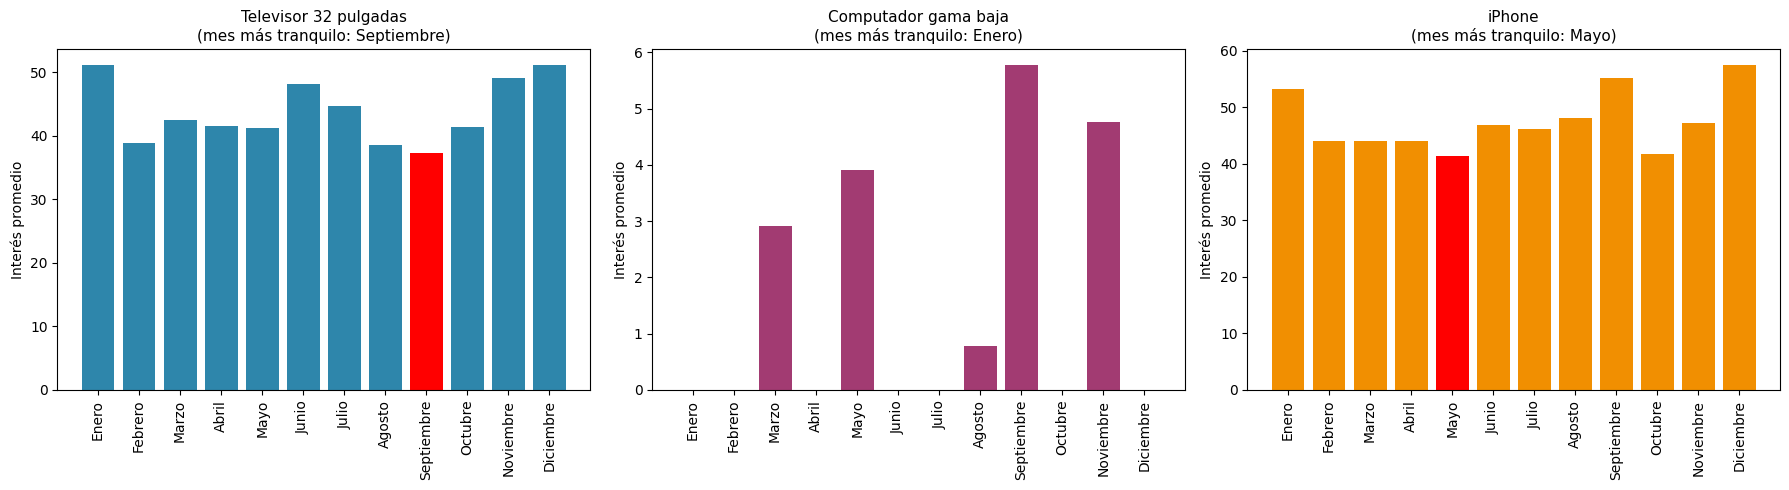

🔴 La barra ROJA marca el mes donde HISTÓRICAMENTE menos gente ha buscado cada producto.


In [8]:
# Graficamos el promedio por mes, como barras, para ver fácil cuál es el mes más "tranquilo"
fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

colores = ["#2E86AB", "#A23B72", "#F18F01"]

for i, nombre in enumerate(datos_tendencias.keys()):
    valores = promedio_por_mes[nombre]
    mes_minimo = valores.idxmin()  # el mes con MENOS búsquedas

    colores_barras = ["red" if mes == mes_minimo else colores[i] for mes in valores.index]
    ejes[i].bar(valores.index, valores.values, color=colores_barras)
    ejes[i].set_title(f"{nombre}\n(mes más tranquilo: {mes_minimo})", fontsize=11)
    ejes[i].tick_params(axis="x", rotation=90)
    ejes[i].set_ylabel("Interés promedio")

plt.tight_layout()
plt.show()

print("🔴 La barra ROJA marca el mes donde HISTÓRICAMENTE menos gente ha buscado cada producto.")


## 7️⃣ Pista #2: ¿Está el dólar "caro" o "barato" en pesos? 💵➡️💰

Los televisores, computadores y celulares en Colombia se compran a fábricas de otros países,
¡y esas fábricas cobran en **dólares**! Así que el precio en pesos también depende de cuántos
pesos cuesta 1 dólar (la "tasa de cambio" o "TRM").

Es como si quisieras comprar dulces en otro país 🍬: si el dólar está "caro" en pesos, tus pesos
alcanzan para MENOS dulces. Si el dólar está "barato" en pesos, ¡tus pesos alcanzan para MÁS!

Vamos a usar una base de datos pública y gratuita llamada **Frankfurter** para ver cómo se ha movido
el dólar frente al peso colombiano en los últimos 2 años.

> 🧩 **Dato curioso:** Frankfurter junta información de más de 50 bancos centrales del mundo. Para el
> peso colombiano (COP), su "fuente experta" es el **Banco de la República de Colombia (BANREP)**,
> que es, ni más ni menos, el banco central de nuestro propio país. Así que le vamos a pedir a
> Frankfurter que nos traiga específicamente los datos que vienen del BANREP. 🇨🇴🏦


In [9]:
# Pedimos el histórico de la tasa de cambio USD -> COP de los últimos 2 años.
# Usamos la versión "v2" de la API de Frankfurter, indicando que la fuente sea el Banco de la
# República de Colombia (providers="BANREP"), que es quien sí tiene datos del peso colombiano.

fecha_inicio = (datetime.now() - timedelta(days=2 * 365)).strftime("%Y-%m-%d")

url_tasa_cambio = "https://api.frankfurter.dev/v2/rates"
parametros_tasa = {
    "base": "USD",
    "quotes": "COP",
    "from": fecha_inicio,
    "providers": "BANREP"
}

tabla_tasa = pd.DataFrame(columns=["fecha", "usd_a_cop"])  # por si algo falla, arrancamos con tabla vacía

try:
    respuesta_tasa = requests.get(url_tasa_cambio, params=parametros_tasa, timeout=20)
    respuesta_tasa.raise_for_status()  # si la API responde con un error, lo detectamos aquí
    datos_tasa = respuesta_tasa.json()

    # En esta versión de la API, cada dato viene como una "fichita" independiente:
    # {"date": "2024-01-02", "base": "USD", "quote": "COP", "rate": 3900.5}
    # Juntamos todas esas fichitas en una sola tabla.
    tabla_tasa = pd.DataFrame(datos_tasa)
    tabla_tasa = tabla_tasa.rename(columns={"date": "fecha", "rate": "usd_a_cop"})
    tabla_tasa["fecha"] = pd.to_datetime(tabla_tasa["fecha"])
    tabla_tasa = tabla_tasa[["fecha", "usd_a_cop"]].sort_values("fecha").reset_index(drop=True)

    print(f"✅ Conseguimos {len(tabla_tasa)} días de historia del dólar frente al peso colombiano.")
    print(f"💵 Valor más reciente: 1 USD = ${tabla_tasa['usd_a_cop'].iloc[-1]:,.2f} COP "
          f"(dato del {tabla_tasa['fecha'].iloc[-1].date()})")

except Exception as error:
    print(f"❌ No se pudo descargar la tasa de cambio en este momento. Error: {error}")
    print("💡 Tip: espera un minuto y vuelve a ejecutar esta celda. Si el problema sigue, revisa tu conexión.")
    print("⚠️ Como no hay datos reales, NO vamos a inventar valores: las gráficas de esta sección quedarán vacías.")

tabla_tasa.tail()


✅ Conseguimos 472 días de historia del dólar frente al peso colombiano.
💵 Valor más reciente: 1 USD = $3,109.30 COP (dato del 2026-09-15)


,fecha,usd_a_cop
467,2026-09-09,3116.47
468,2026-09-10,3099.48
469,2026-09-11,3101.00
470,2026-09-12,3072.27
471,2026-09-15,3109.30


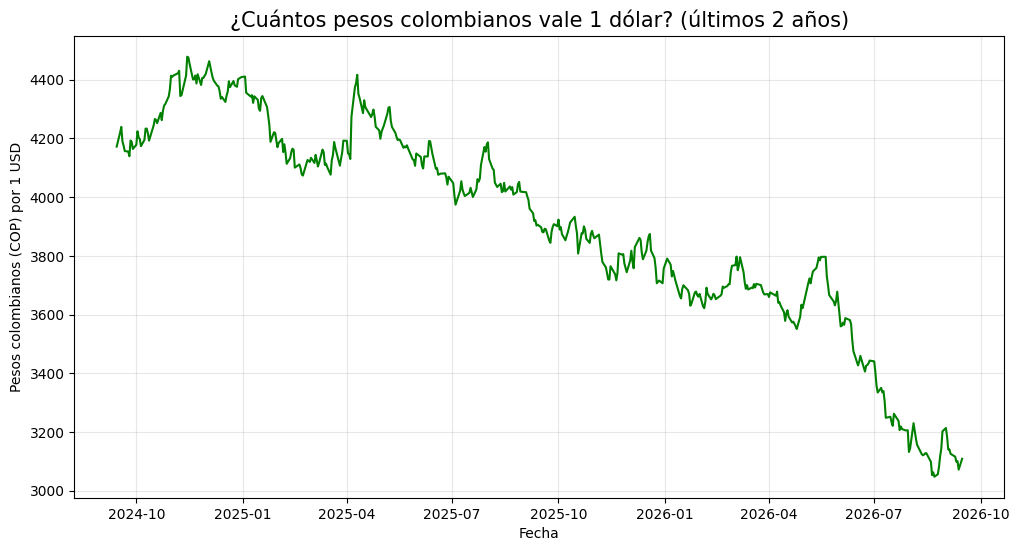

In [10]:
# Graficamos cómo se ha movido el dólar en pesos colombianos
if not tabla_tasa.empty:
    plt.figure()
    plt.plot(tabla_tasa["fecha"], tabla_tasa["usd_a_cop"], color="green")
    plt.title("¿Cuántos pesos colombianos vale 1 dólar? (últimos 2 años)", fontsize=15)
    plt.xlabel("Fecha")
    plt.ylabel("Pesos colombianos (COP) por 1 USD")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("⚠️ No hay datos del dólar para graficar (la celda anterior no pudo descargarlos).")


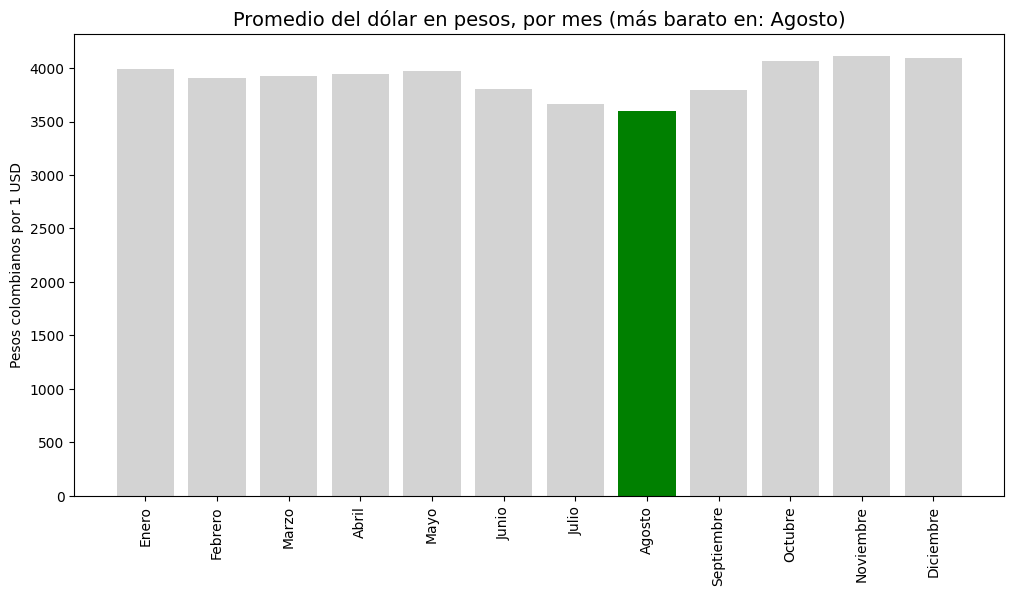

🟢 Históricamente, el mes donde el dólar ha estado MÁS BARATO en pesos es: Agosto
   (Esto es una buena señal para comprar productos importados, aunque no es una garantía)


In [11]:
# Igual que con los productos, calculamos el promedio de la tasa de cambio POR MES,
# para ver si hay meses donde el dólar suele estar más "barato" (mejor para comprar productos importados)
mes_dolar_mas_barato = None  # por si no hay datos, dejamos esto en None

if not tabla_tasa.empty:
    tabla_tasa["mes"] = tabla_tasa["fecha"].dt.month
    promedio_tasa_por_mes = tabla_tasa.groupby("mes")["usd_a_cop"].mean()
    promedio_tasa_por_mes.index = promedio_tasa_por_mes.index.map(nombres_meses_es)

    mes_dolar_mas_barato = promedio_tasa_por_mes.idxmin()

    plt.figure()
    colores_barras_tasa = ["green" if mes == mes_dolar_mas_barato else "lightgray" for mes in promedio_tasa_por_mes.index]
    plt.bar(promedio_tasa_por_mes.index, promedio_tasa_por_mes.values, color=colores_barras_tasa)
    plt.title(f"Promedio del dólar en pesos, por mes (más barato en: {mes_dolar_mas_barato})", fontsize=14)
    plt.xticks(rotation=90)
    plt.ylabel("Pesos colombianos por 1 USD")
    plt.show()

    print(f"🟢 Históricamente, el mes donde el dólar ha estado MÁS BARATO en pesos es: {mes_dolar_mas_barato}")
    print("   (Esto es una buena señal para comprar productos importados, aunque no es una garantía)")
else:
    print("⚠️ No hay datos del dólar disponibles, así que nos saltamos esta parte del análisis.")


## 8️⃣ Pista #3: Las fechas de descuentos que ya conocemos en Colombia 🎉

Además de las búsquedas y el dólar, en Colombia existen **fechas oficiales de descuentos** que se
repiten cada año. Las anotamos aquí como nuestra "pista extra":

| Evento | Cuándo suele ser | Nota |
|---|---|---|
| 🏷️ Día sin IVA | 2 o 3 fechas al año (marzo, julio, noviembre aprox.) | Fechas exactas las confirma el Gobierno cada año |
| 🛒 Hot Sale Colombia | Mayo o junio | Organizado por la Cámara Colombiana de Comercio Electrónico |
| 🖤 Black Friday | Último viernes de noviembre | Muy fuerte en tecnología |
| 💻 Cyber Monday | Lunes después del Black Friday | Enfocado en compras online |
| 🎄 Temporada de Navidad | Diciembre | Más ofertas, pero también más gente comprando |
| 🎒 Regreso a clases | Enero | Buen momento para computadores |

> ⚠️ Para 2026, las fechas tentativas (no oficiales todavía) del Día sin IVA son:
> **21 de marzo**, **19 de julio** y **29 de noviembre**. El Gobierno las confirma más cerca de la fecha,
> así que siempre revisa la fecha oficial antes de planear tu compra. 📅


In [12]:
# Escribimos el calendario de eventos como una tabla, para poder combinarlo con nuestras otras pistas
calendario_descuentos = pd.DataFrame([
    {"evento": "Día sin IVA (1)", "mes": 3, "nombre_mes": "Marzo", "categoria": "General"},
    {"evento": "Hot Sale Colombia", "mes": 5, "nombre_mes": "Mayo", "categoria": "General"},
    {"evento": "Día sin IVA (2)", "mes": 7, "nombre_mes": "Julio", "categoria": "General"},
    {"evento": "Black Friday / Día sin IVA (3)", "mes": 11, "nombre_mes": "Noviembre", "categoria": "Tecnología"},
    {"evento": "Cyber Monday", "mes": 11, "nombre_mes": "Noviembre", "categoria": "Tecnología"},
    {"evento": "Temporada Navidad", "mes": 12, "nombre_mes": "Diciembre", "categoria": "General"},
    {"evento": "Regreso a clases", "mes": 1, "nombre_mes": "Enero", "categoria": "Computadores"},
])

print("🗓️ Calendario de descuentos conocidos en Colombia:")
calendario_descuentos


🗓️ Calendario de descuentos conocidos en Colombia:


,evento,mes,nombre_mes,categoria
0,Día sin IVA (1),3,Marzo,General
1,Hot Sale Colombia,5,Mayo,General
2,Día sin IVA (2),7,Julio,General
3,Black Friday / Día sin IVA (3),11,Noviembre,Tecnología
4,Cyber Monday,11,Noviembre,Tecnología
5,Temporada Navidad,12,Diciembre,General
6,Regreso a clases,1,Enero,Computadores


## 9️⃣ ¡El detective junta todas las pistas! 🕵️‍♂️🧩

Ahora sí, el momento de la verdad. Vamos a combinar nuestras 3 pistas para cada producto:

- 🔎 Pista 1: mes con MENOS búsquedas (menos demanda → más probable que haya descuentos)
- 💵 Pista 2: mes con el dólar más barato (mejor para productos importados)
- 🎉 Pista 3: si en ese mes (o cerca) hay algún evento oficial de descuentos

Con eso armamos una recomendación final para cada producto. 🎯


In [13]:
def evento_cercano(mes, calendario, margen=1):
    """
    Esta función revisa si hay algún evento de descuentos CERCA de un mes dado.
    Por ejemplo, si el mes es Octubre (10) y el margen es 1, revisa Septiembre, Octubre y Noviembre.
    Es como preguntar: '¿hay alguna fiesta cerca de mi cumpleaños?' 🎂
    """
    meses_cercanos = [((mes - 1 + i) % 12) + 1 for i in range(-margen, margen + 1)]
    eventos_encontrados = calendario[calendario["mes"].isin(meses_cercanos)]
    return eventos_encontrados["evento"].tolist()


recomendaciones = []

for nombre in datos_tendencias.keys():
    mes_num_menos_busqueda = df_tendencias.groupby("mes")[nombre].mean().idxmin()
    mes_nombre_menos_busqueda = nombres_meses_es[mes_num_menos_busqueda]

    eventos_cerca = evento_cercano(mes_num_menos_busqueda, calendario_descuentos, margen=1)

    # Armamos un mensaje explicando el "porqué" de la recomendación
    if eventos_cerca:
        razon = f"Poca gente lo busca en este mes, y además coincide con: {', '.join(eventos_cerca)}."
        confianza = "Alta 🟢"
    else:
        razon = "Es el mes con menos búsquedas del año, aunque no coincide con un evento oficial conocido."
        confianza = "Media 🟡"

    recomendaciones.append({
        "Producto": nombre,
        "Mejor mes para comprar": mes_nombre_menos_busqueda,
        "Por qué": razon,
        "Confianza": confianza
    })

tabla_recomendaciones = pd.DataFrame(recomendaciones)

print("🏆 RECOMENDACIÓN FINAL POR PRODUCTO:\n")
tabla_recomendaciones


🏆 RECOMENDACIÓN FINAL POR PRODUCTO:



,Producto,Mejor mes para comprar,Por qué,Confianza
0,Televisor 32 pulgadas,Septiembre,"Es el mes con menos búsquedas del año, aunque ...",Media 🟡
1,Computador gama baja,Enero,"Poca gente lo busca en este mes, y además coin...",Alta 🟢
2,iPhone,Mayo,"Poca gente lo busca en este mes, y además coin...",Alta 🟢


## 🔟 Reporte final: el resumen del detective 📋

Por último, armamos un reporte completo con todo lo que descubrimos, como el resumen que escribes
al final de un trabajo de investigación en el colegio. 🎓


In [14]:
print("=" * 65)
print("📋 REPORTE FINAL - MEJOR MOMENTO DEL AÑO PARA COMPRAR")
print("   (Televisor 32'' | Computador gama baja | iPhone)")
print("=" * 65)

for fila in recomendaciones:
    print(f"\n📦 {fila['Producto']}")
    print(f"   🗓️  Mejor mes recomendado: {fila['Mejor mes para comprar']}")
    print(f"   💡 Razón: {fila['Por qué']}")
    print(f"   🎯 Nivel de confianza: {fila['Confianza']}")

if mes_dolar_mas_barato:
    print(f"\n💵 Dato extra: el dólar históricamente ha estado más barato en {mes_dolar_mas_barato},")
    print("   lo cual es una buena señal adicional para los 3 productos, ya que todos son importados.")
else:
    print("\n💵 Dato extra: no fue posible obtener el histórico del dólar en esta ejecución,")
    print("   así que la recomendación se basó solo en las búsquedas y el calendario de descuentos.")

print("\n" + "=" * 65)
print("🔎 CONCLUSIONES ADICIONALES")
print("=" * 65)
print("""
1) Los 3 productos son importados, así que el precio del dólar SIEMPRE afecta su costo final
   en pesos colombianos, sin importar la tienda.

2) Los meses de menor búsqueda no garantizan un descuento, pero SÍ muestran que hay menos
   competencia entre compradores, lo cual históricamente motiva a las tiendas a ofrecer promociones.

3) Los eventos oficiales (Día sin IVA, Black Friday, Cyber Monday) suelen dar los descuentos
   MÁS GRANDES y seguros del año, incluso si no coinciden exactamente con el mes de menor búsqueda.

4) El iPhone suele tener un comportamiento especial: cuando Apple lanza un modelo nuevo
   (usualmente en septiembre), el modelo anterior baja de precio. Vale la pena revisar el
   calendario de lanzamientos de Apple como una pista adicional.

5) Recomendación general: la MEJOR estrategia es comprar en un mes de baja demanda que además
   coincida con un evento oficial de descuentos. Ahí es donde se juntan las 3 pistas. 🎯
""")

print("⚠️ Recuerda: estas son predicciones basadas en patrones históricos públicos (búsquedas y tasa de")
print("   cambio), NO son precios garantizados de Alkosto. Siempre verifica el precio real antes de comprar.")


📋 REPORTE FINAL - MEJOR MOMENTO DEL AÑO PARA COMPRAR
   (Televisor 32'' | Computador gama baja | iPhone)

📦 Televisor 32 pulgadas
   🗓️  Mejor mes recomendado: Septiembre
   💡 Razón: Es el mes con menos búsquedas del año, aunque no coincide con un evento oficial conocido.
   🎯 Nivel de confianza: Media 🟡

📦 Computador gama baja
   🗓️  Mejor mes recomendado: Enero
   💡 Razón: Poca gente lo busca en este mes, y además coincide con: Temporada Navidad, Regreso a clases.
   🎯 Nivel de confianza: Alta 🟢

📦 iPhone
   🗓️  Mejor mes recomendado: Mayo
   💡 Razón: Poca gente lo busca en este mes, y además coincide con: Hot Sale Colombia.
   🎯 Nivel de confianza: Alta 🟢

💵 Dato extra: el dólar históricamente ha estado más barato en Agosto,
   lo cual es una buena señal adicional para los 3 productos, ya que todos son importados.

🔎 CONCLUSIONES ADICIONALES

1) Los 3 productos son importados, así que el precio del dólar SIEMPRE afecta su costo final
   en pesos colombianos, sin importar la tienda.


## ➕ Extra: ver el precio del dólar ahora mismo 🔄

Puedes volver a ejecutar esta celda cuando quieras para ver la tasa de cambio USD/COP más reciente.


In [15]:
respuesta_actual = requests.get(
    "https://api.frankfurter.dev/v2/rate/USD/COP",
    params={"providers": "BANREP"},
    timeout=15
)
datos_actuales_tasa = respuesta_actual.json()

valor_actual = datos_actuales_tasa["rate"]
fecha_actual = datos_actuales_tasa["date"]

print(f"💵 Tasa de cambio más reciente: 1 USD = ${valor_actual:,.2f} COP")
print(f"📅 Fecha del dato: {fecha_actual}")


💵 Tasa de cambio más reciente: 1 USD = $3,109.30 COP
📅 Fecha del dato: 2026-09-15
